In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp

**The following content is borrowed from JHEP 02 (2025) 141, axXiv:2307.14418**

Consider the free Fermi gas, the energy, pressure  and scalar number densities ($\varepsilon_\psi$, $p_\psi$ and $\rho_s$ respectively) of the baryon are given by
\begin{alignat}{1}
\varepsilon_\psi(m_*(\theta),\rho) &= 2 \int_0^{k_F(\rho)}\frac{d^3k}{(2\pi)^3}\sqrt{\mathbf{k}^2+m_*^2(\theta)} = \frac{m_*^4}{8\pi^2}[x(2x^2+1)\sqrt{x^2+1}-\sinh^{-1}(x)] \\
p_\psi(m_*(\theta),\rho) &= \frac{2}{3} \int_0^{k_F(\rho)}\frac{d^3k}{(2\pi)^3}\frac{k^2}{\sqrt{\mathbf{k}^2+m_*^2(\theta)}} = \frac{m_*^4}{24\pi^2}[x(2x^2-3)\sqrt{x^2+1}+3\sinh^{-1}(x)] \\
\rho_s(m_*(\theta),\rho)& = \frac{\varepsilon_\psi-3p_\psi}{m_*}
\end{alignat}
where $x=k_F(\rho)/m_*$ and $k_F(\rho)=(3\pi^2\rho)^{1/3}$.

We define the axion potential
$$
V(\theta) = -m_\pi^2 f_\pi^2 F(\theta)
$$
where
$$
F(\theta)=\sqrt{1-z_{ud}\sin^2\left(\frac{\theta}{2}\right)}-1
$$
and the scalar-dependent femion mass
$$
m_*(\theta)=m_N +\sigma_{\pi N} F(\theta). 
$$
The parameters $z_{ud}=4m_u m_d/(m_u+m_d)^2\approx 0.88$, $\sigma_{\pi N}\approx 50~{\rm MeV}$ and $f_\pi \approx 93~{\rm MeV}$.

In [4]:
# constants
zud, sigPiN, fpi, mpi, mN, G,mp = 0.88, 50, 93, 135, 938, 1 / (2.435e21)**2,938
km_to_MeV = 5.06842e15 # 1km to 1/MeV
MeV4_to_MeVperfm3 = (5.06842e-3)**3 # MeV^4 to MeV/fm^3
M_sun = 1.116e60 # Solar mass in MeV

def kF(rho):
    """
    Fermi momentum

    In
    --
    rho : scalar
        Scalar number density, MeV^3

    Out
    ---
    out : scalar
        Fermi momentum, MeV
    """
    return (3 * np.pi**2 * rho)**(1/3)

def energy_psi(ms,rho):
    """
    Scalar energy density

    In
    --
    ms : scalar
        Scalar mass, MeV
    rho : scalar
        Scalar number density, MeV^3

    Out
    ---
    out : scalar
        Baryon energy density, MeV^4
    """
    x = kF(rho) / ms
    e = ms ** 4 * (x * (2 * x**2 + 1) * np.sqrt(x**2 + 1) - np.arcsinh(x)) / 8 / np.pi**2
    return e

def pressure_psi(ms,rho):
    """
    Scalar pressure

    In
    --
    ms : scalar
        Scalar mass, MeV
    rho : scalar
        Scalar number density, MeV^3

    Out
    ---
    out : scalar
        Baryon pressure, MeV^4
    """
    x = kF(rho) / ms
    p = ms ** 4 * (x * (2 * x**2 - 3) * np.sqrt(x**2 + 1) + 3 * np.arcsinh(x)) / 24 / np.pi**2
    return p

def rho_scalar(e_psi,p_psi,ms):
    """
    Scalar number density

    In
    --
    e_psi : scalar
        Energy density, MeV^4
    p_psi : scalar
        Pressure, MeV^4
    ms : scalar
        Scalar mass, MeV

    Out
    ---
    out : scalar
        Scalar number density, MeV^3
    """
    return (e_psi - 3 * p_psi) / ms

def F(theta):
    return np.sqrt(1 - zud * np.sin(theta / 2)**2) - 1

def axion_potential(theta):
    """
    Axion potential

    In
    --
    theta : scalar
        Normalized axion field, phi/f

    Out
    ---
    out : scalar
        Axion potential, MeV^4
    """
    return - (mpi * fpi)**2 * F(theta)

def m_scalar(theta):
    """
    Scalar mass (baryon mass subject to axion correction)

    In
    --
    theta : scalar
        Normalized axion field, phi/f

    Out
    ---
    out : scalar
        Scalar mass, MeV
    """
    return mN + sigPiN * F(theta)


Note that in solving the TOV, when the values of $p_\psi$ and $\theta$ are assigned, we can solve for $\rho$ by inversing $p_\psi$ numerically. To be precisely, this $\rho$ is not $\rho_s$.

In [6]:
def get_rho(p_psi,theta,rho0=1e10):
    """
    Find rho for a given scalar pressure and axion field

    In
    --
    p_psi : scalar
        Scalar pressure, MeV^4
    theta : scalar
        Normalized axion field, phi/f

    Out
    ---
    out : scalar
        Number density rho, MeV^4
    """
    ms = m_scalar(theta)
    def _f(rho):
        return pressure_psi(ms,rho) - p_psi

    rho = root_scalar(_f, x0=rho0).root
    return rho

To solve the TOV, the equation of states are shifted by the presence of axion field
$$
\varepsilon = \varepsilon_\psi(m_*,\rho)+V(\theta)\quad {\rm and}\quad p=p_\psi(m_*,\rho) - V(\theta)
$$

In [8]:
def energy(ms,rho,theta):
    """
    Total energy density (baryon + axion)

    In
    --
    ms : scalar
        Scalar mass, MeV
    rho : scalar
        Scalar number density, MeV^3
    theta : scalar
        Normalized axion field, phi/f

    Out
    ---
    out : scalar
        Total energy density (baryon + axion), MeV^4
    """
    return energy_psi(ms,rho) + axion_potential(theta)

def pressure(ms,rho,theta):
    """
    Total pressure (baryon + axion)

    In
    --
    ms : scalar
        Scalar mass, MeV
    rho : scalar
        Scalar number density, MeV^3
    theta : scalar
        Normalized axion field, phi/f

    Out
    ---
    out : scalar
        Total pressure (baryon + axion), MeV^4
    """
    return pressure_psi(ms,rho) - axion_potential(theta)

The TOV in the presence of axion field is given by
\begin{alignat}{1}
\theta^{\prime \prime}\left(1-\frac{2GM}{r}\right) &= -\frac{2}{r}\theta^\prime\left[1-\frac{GM}{r}-2\pi Gr^2(\varepsilon-p)\right] + \frac{1}{f^2}\left(\frac{\partial V}{\partial \theta}+\rho_s\frac{\partial m_*}{\partial \theta}\right), \\
p^\prime &= -\frac{GM\varepsilon}{r^2}\left(1+\frac{p}{\varepsilon}\right)\left(1-\frac{2GM}{r}\right)^{-1}\left\{1+\frac{4\pi r^3}{M}\left[p+\frac{f^2 \theta^{\prime 2}}{2}\left(1-\frac{2GM}{r}\right)\right]\right\} - \theta^\prime \left(\frac{\partial V}{\partial \theta}+\rho_s\frac{\partial m_*}{\partial \theta}\right), \\
M^\prime &= 4\pi r^2\left[\varepsilon + \frac{f^2\theta^{\prime 2}}{2}\left(1-\frac{2GM}{r}\right)\right].
\end{alignat}
where
$$
\frac{\partial V}{\partial \theta}= \frac{m_\pi^2 f_\pi^2 z_{ud}}{4}\frac{\sin\theta}{\sqrt{1-z_{ud}\sin^2\frac{\theta}{2}}}\quad{\rm and}\quad
\frac{\partial m_*}{\partial \theta}= -\frac{\sigma_{\pi N} z_{ud}}{2}\frac{\sin\theta}{\sqrt{1-z_{ud}\sin^2\frac{\theta}{2}}}
$$

In [10]:
def V_prime(theta):
    """
    Derivative of axion potential wrt normalized axion field, MeV^4
    """
    dF = np.sin(theta) / np.sqrt(1 - zud * np.sin(theta / 2)**2)
    return mpi**2 * fpi**2 * zud * dF / 4

def ms_prime(theta):
    """
    Derivative of scalar mass wrt normalized axion field, MeV
    """
    dF = np.sin(theta) / np.sqrt(1 - zud * np.sin(theta / 2)**2)
    return - sigPiN * zud * dF / 2

Numerically, we spilt the 2nd-order ODE $\theta^{\prime \prime}$ into two 1st-order ODEs. Define $\eta = \theta$ and $\xi = \theta^\prime$. Hence we rewrite the first equation into
\begin{alignat}{1}
\eta^\prime &= \xi, \\
\xi ^\prime &= \left\{ -\frac{2}{r}\xi\left[1-\frac{GM}{r}-2\pi Gr^2(\varepsilon-p)\right] + \frac{1}{f^2}\left(\frac{\partial V}{\partial \eta}+\rho_s\frac{\partial m_*}{\partial \eta}\right)\right\}\left(1-\frac{2GM}{r}\right)^{-1}.
\end{alignat}
Note that all $\theta$ and $\theta^\prime$ dependent terms are replaced with $\eta$ and $\xi$ respectively. Furthermore
\begin{alignat}{1}
p^\prime &= -\frac{GM\varepsilon}{r^2}\left(1+\frac{p}{\varepsilon}\right)\left(1-\frac{2GM}{r}\right)^{-1}\left\{1+\frac{4\pi r^3}{M}\left[p+\frac{f^2 \xi^2}{2}\left(1-\frac{2GM}{r}\right)\right]\right\} - \xi \left(\frac{\partial V}{\partial \eta}+\rho_s\frac{\partial m_*}{\partial \eta}\right), \\
M^\prime &= 4\pi r^2\left[\varepsilon + \frac{f^2\xi^2}{2}\left(1-\frac{2GM}{r}\right)\right].
\end{alignat}

In [12]:
def tov_eqs(r,y,f=1e19):
    """
    r: distance to initial r0, 1/MeV
    y: the TOV ODEs [deta,dxi,dp,dM], all in natural units
    f: axion coupling f, MeV, can be inserted via "args" in solve_ivp
    """
    # extract ODE numerics
    eta,xi,p,M = y 
    
    # note that eta = theta
    V = axion_potential(eta) # axion potential
    ms = m_scalar(eta) # scalar mass
    p_psi = p + V # baryon pressure
    rho = get_rho(p_psi,eta,rho0=p_psi) # number density rho
    e_psi = energy_psi(ms,rho)
    
    # Parameters for TOV
    dV = V_prime(eta)
    dms = ms_prime(eta)
    rho_s = rho_scalar(e_psi,p_psi,ms) # scalar number density
    e = energy(ms,rho,eta)
    GM_r = G * M / r 

    # TOV
    deta = xi
    dxi = (- 2 * xi / r * (1 - GM_r - 2 * np.pi * G * r**2 * (e - p)) + (dV + rho_s * dms) / f**2) / (1 - 2 * GM_r)
    dp = - GM_r / r * (e + p) / (1 - 2 * GM_r) * (1 + 4 * np.pi * r**3 / M * (p + f**2 * xi**2 / 2 * (1 - 2 * GM_r))) - xi * (dV + rho_s * dms)
    dM = 4 * np.pi * r**2 * (e + f**2 * xi**2 / 2 * (1 - 2 * GM_r))
    return [deta,dxi,dp,dM]

def initial_conditions(p0,theta0,r0):
    """
    p0: Central pressure, MeV/fm^3
    theta0: 0 to pi
    r0: Initial point, km
    """
    r0 = r0 * 5.06842e15 # km to 1/MeV
    p0 = p0 / (5.06842e-3)**3 # MeV/fm^3 to MeV^4
    p_psi0 = p0 + axion_potential(theta0)
    rho0 = get_rho(p_psi0,theta0,rho0=1e10)
    ms0 = m_scalar(theta0)
    e0 = energy(ms0,rho0,theta0)
    M0 = 4 * np.pi * r0**3 * e0 / 3
    return [theta0,0,p0,M0] # eta0,xi0,p0,M0 all in nautral units

In [13]:
f=1e16
p0 = 100
theta0 = 0.9*np.pi
r0 = 1e-3 # km

y0 = initial_conditions(p0,theta0,r0) # y0 is the initial condition
p_stop = y0[2] / 1e4 # if p is 10000 times smaller than p0, stop the solver

def _stop_event(r,y,f):
    p = y[2] # get the current pressure
    return p - p_stop
# Stop criteria
_stop_event.terminal = True 
_stop_event.direction = -1

r_span = np.logspace(-3,1.5,1000) * km_to_MeV # The tov is written in natural units, everything has to be converted into natural units
tov_solutions = solve_ivp(tov_eqs,[r_span[0],r_span[-1]],y0,t_eval=r_span,args=(f,),events=_stop_event)

Text(0.5, 1.0, '$\\theta_0=0.90\\pi$')

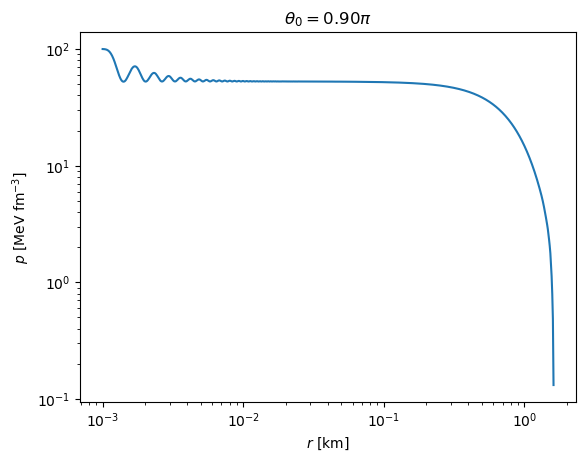

In [14]:
plt.plot(tov_solutions.t/km_to_MeV,tov_solutions.y[2]*MeV4_to_MeVperfm3)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$r$ [km]')
plt.ylabel(r'$p$ [MeV fm$^{-3}$]')
plt.title(fr'$\theta_0={theta0/np.pi:.2f}\pi$')

Text(0.5, 1.0, '$\\theta_0=0.90\\pi$')

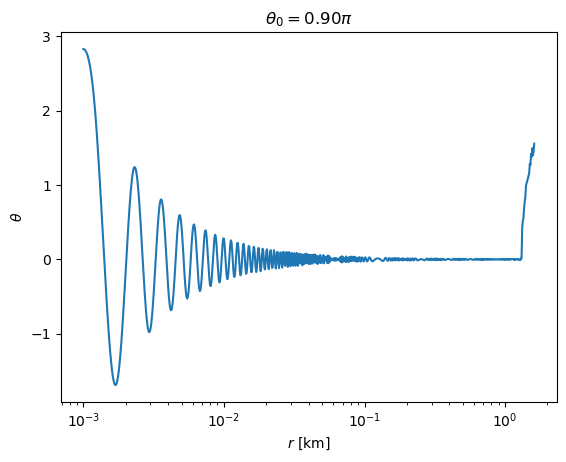

In [15]:
plt.plot(tov_solutions.t/km_to_MeV,tov_solutions.y[0])
#plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$r$ [km]')
plt.ylabel(r'$\theta$')
plt.title(fr'$\theta_0={theta0/np.pi:.2f}\pi$')

Text(0.5, 1.0, '$\\theta_0=0.9\\pi$')

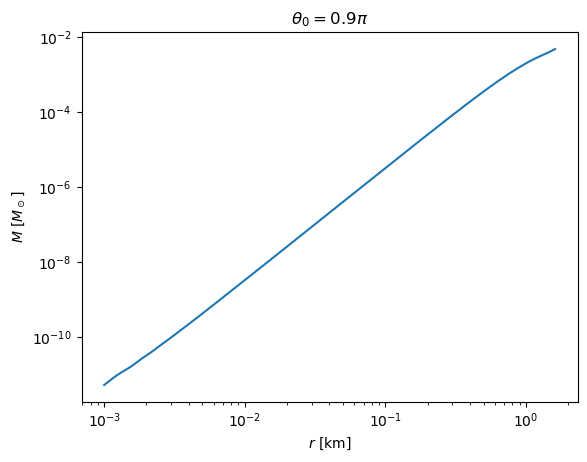

In [16]:
plt.plot(tov_solutions.t/km_to_MeV,tov_solutions.y[-1]/M_sun)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$r$ [km]')
plt.ylabel(r'$M~[M_\odot]$')
plt.title(r'$\theta_0=0.9\pi$')